In [1]:
# data: mall_customers.csv

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [76]:
df.shape

(200, 5)

In [77]:
# separate input data

x = df.iloc[:,[3,4]]

In [78]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [79]:
x.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

#### Visualize the data

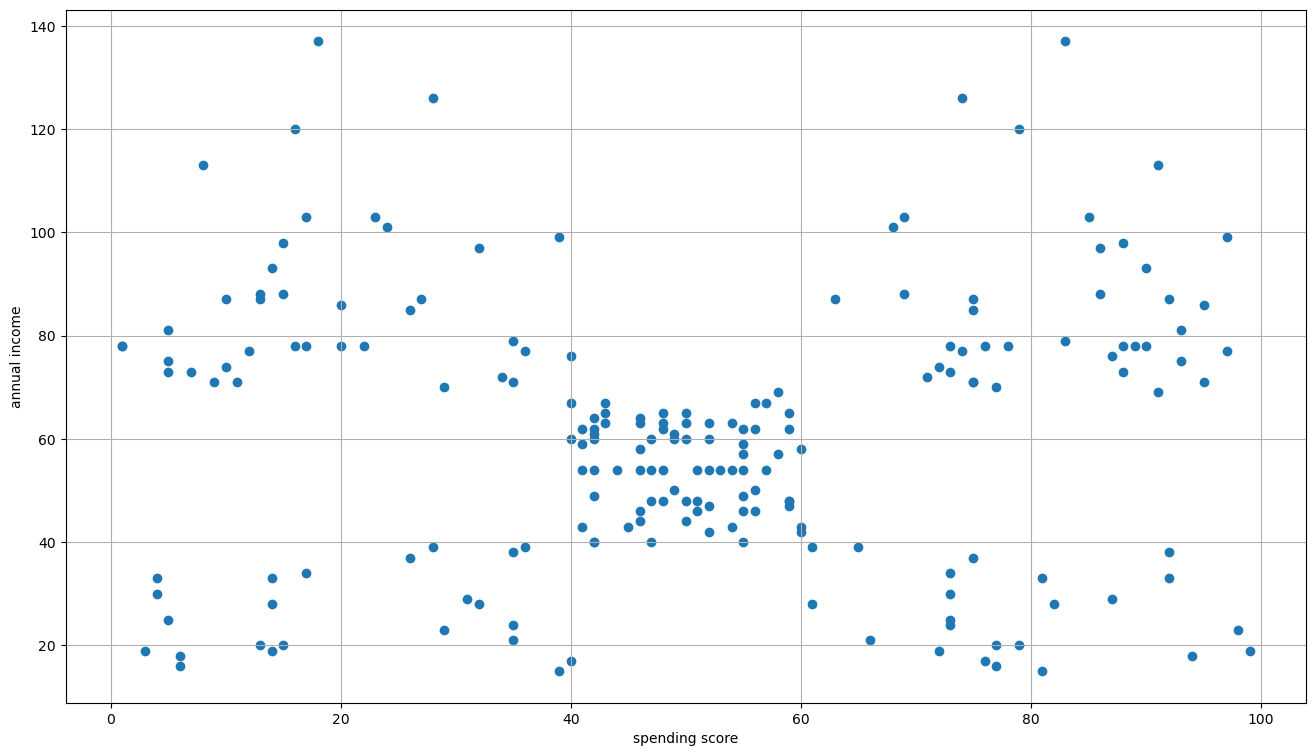

In [80]:
plt.figure(figsize=(16,9))
plt.xlabel('spending score')
plt.ylabel('annual income')
plt.scatter(df['Spending Score (1-100)'], df['Annual Income (k$)'])
plt.grid()

#### Build the model

In [81]:
from sklearn.cluster import KMeans

In [82]:
km = KMeans(n_clusters= 3, random_state= 0)

In [83]:
labels = km.fit_predict(x)

In [84]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [85]:
km.inertia_

106348.37306211122

#### Elbow Method

In [86]:
import warnings 
warnings.filterwarnings('ignore')

In [87]:
sse = []

for k in range(1,26):
    km = KMeans(n_clusters= k, random_state= 0)
    km.fit_predict(x)
    sse.append(km.inertia_)

In [88]:
sse

[269981.28,
 181363.59595959593,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37265.86520484346,
 30259.65720728547,
 25050.832307547527,
 21862.092672182895,
 19657.78360870395,
 17584.589416163646,
 16032.113097679265,
 14523.258112983116,
 13000.92742551566,
 12072.54244921745,
 11244.080745305746,
 10379.038632763632,
 9449.618106209411,
 8854.212091503268,
 8454.191053391054,
 7698.198746867167,
 7246.878628389155,
 7100.48484940985,
 6516.043941833881,
 6221.174236934563]

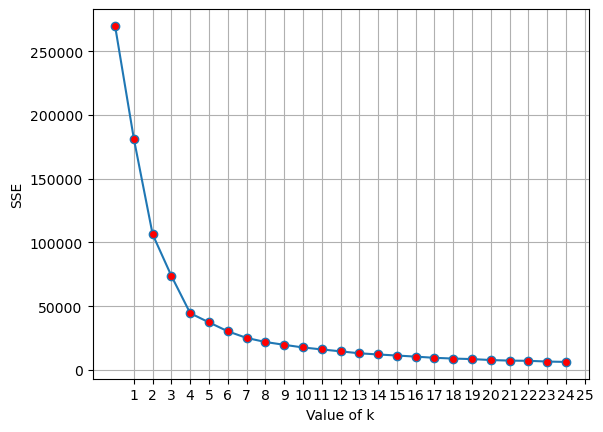

In [89]:
plt.xlabel('Value of k')
plt.ylabel('SSE')
plt.xticks(range(1,26))
plt.plot(sse, marker = 'o', mfc = 'r')
plt.grid()

In [90]:
# !pip install kneed

In [91]:
from kneed import KneeLocator

In [92]:
kl = KneeLocator(range(1,26), sse, curve= 'convex',
                direction= 'decreasing')

In [93]:
kl.elbow

5

#### Silhouette method

In [94]:
from sklearn.metrics import silhouette_score

In [95]:
silh = []

for k in range(2,16):
    km = KMeans(n_clusters= k, random_state= 0)
    labels = km.fit_predict(x)
    score = silhouette_score(x, labels)
    silh.append(score)

In [96]:
silh

[0.2968969162503008,
 0.46761358158775435,
 0.4931963109249047,
 0.553931997444648,
 0.5379675585622219,
 0.5264283703685728,
 0.45544193969058644,
 0.4553729779390266,
 0.44760979994374317,
 0.4472950813160941,
 0.4323888233160193,
 0.4309886380247191,
 0.4202217866258089,
 0.4234508184777198]

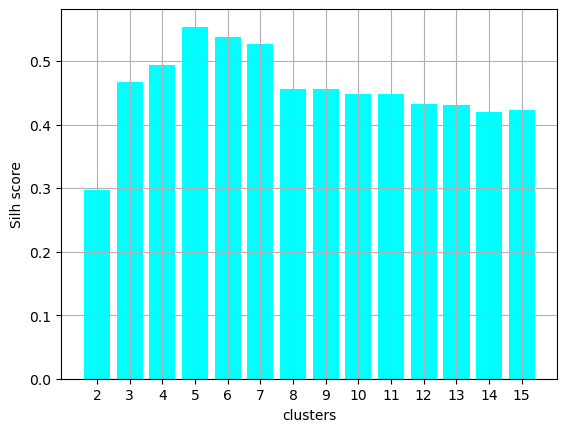

In [97]:
plt.xlabel('clusters')
plt.ylabel('Silh score')
plt.grid()
plt.xticks(range(2,16))
plt.bar(range(2,16), silh, color = 'cyan');

In [98]:
km = KMeans(n_clusters= 5, random_state= 0)

In [99]:
labels = km.fit_predict(x)

In [100]:
labels

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [37]:
km.inertia_

44448.4554479337

In [45]:
cent = km.cluster_centers_

In [46]:
cent

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

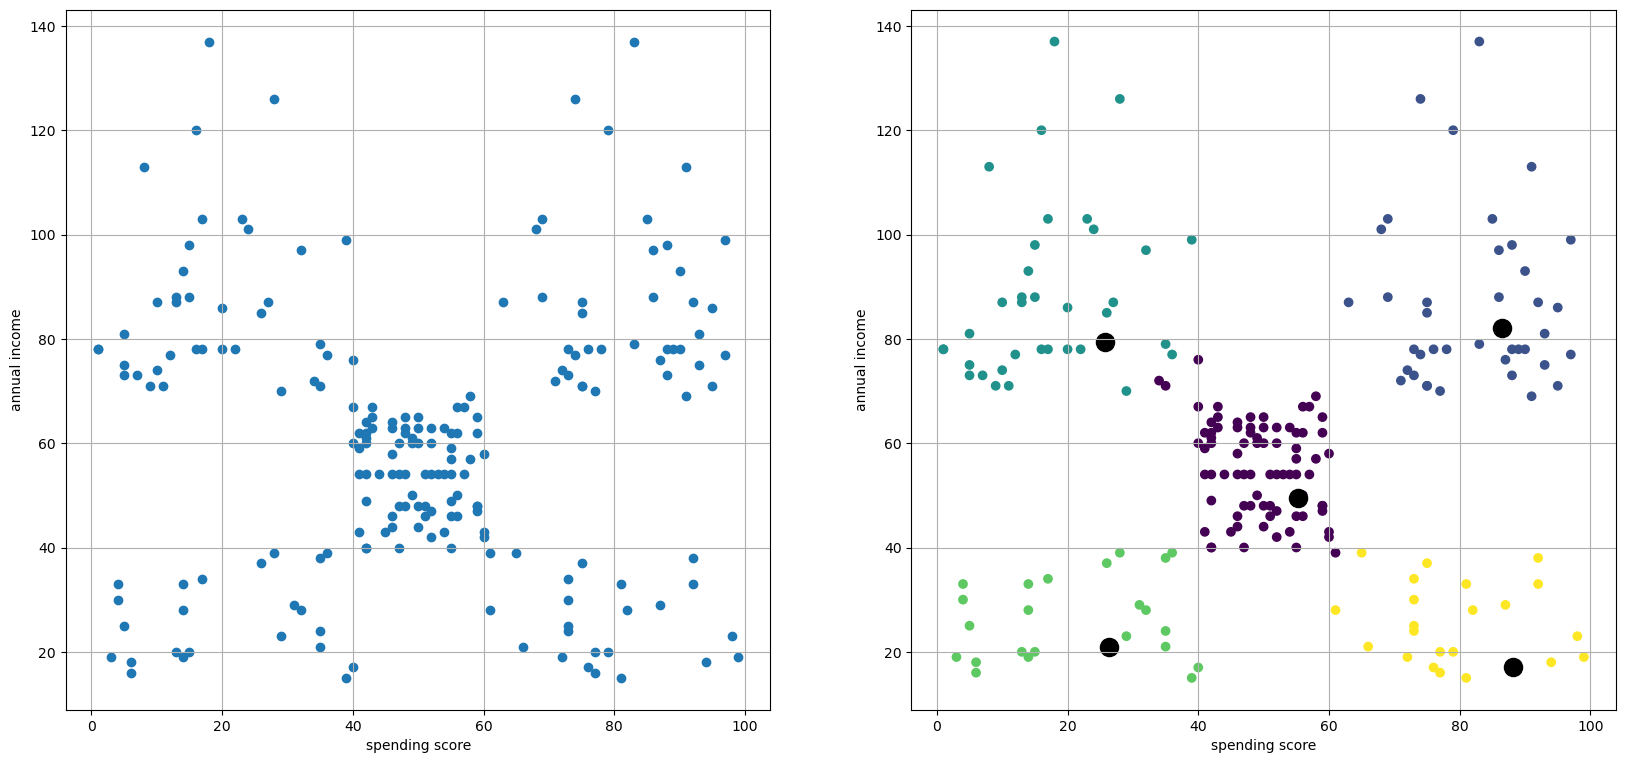

In [51]:
plt.figure(figsize=(20,20))

plt.subplot(2,2,1)
plt.xlabel('spending score')
plt.ylabel('annual income')
plt.scatter(df['Spending Score (1-100)'], df['Annual Income (k$)'])
plt.grid()


plt.subplot(2,2,2)
plt.xlabel('spending score')
plt.ylabel('annual income')
plt.scatter(df['Spending Score (1-100)'], df['Annual Income (k$)'],
           c = labels)
plt.grid()
plt.scatter(cent[:,0], cent[:,1], s = 170, color = 'black');

### filter out clusters

In [52]:
zero = df[labels == 0]

In [53]:
zero.shape

(81, 5)

In [54]:
one = df[labels == 1]
two = df[labels == 2]
three = df[labels == 3]
four = df[labels == 4]

### Export the cluster

In [55]:
three.to_csv('three.csv', index = False)

### predict on new data

In [56]:
new1 = [[45, 62]]
new2 = [[15, 57]]

In [57]:
km.predict(new1)

array([0], dtype=int32)

In [58]:
km.predict(new2)

array([4], dtype=int32)

###### driver data

In [59]:
df = pd.read_csv('driver-data.csv')
df

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [60]:
x = df.iloc[:,[1,2]]

In [61]:
x

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25
...,...,...
3995,160.04,10
3996,176.17,5
3997,170.91,12
3998,176.14,5


In [62]:
x.columns

Index(['mean_dist_day', 'mean_over_speed_perc'], dtype='object')

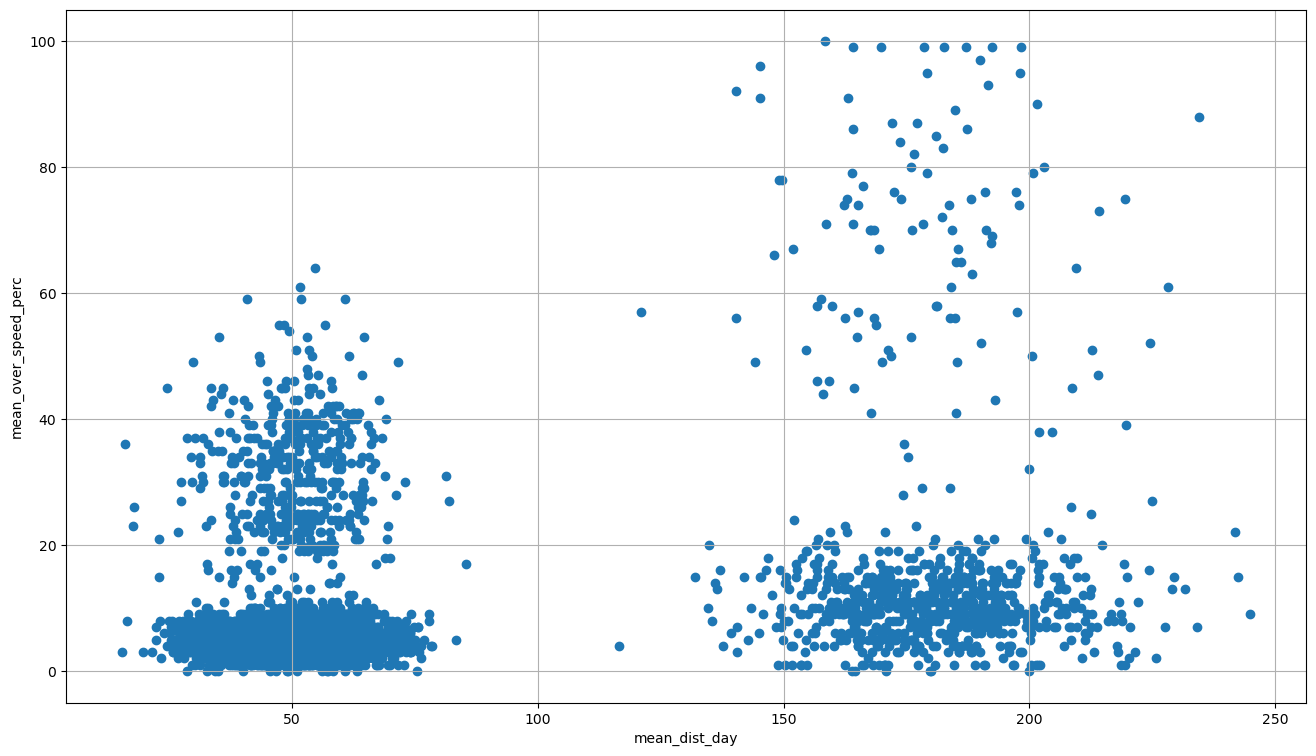

In [73]:
plt.figure(figsize=(16,9))
plt.xlabel('mean_dist_day')
plt.ylabel('mean_over_speed_perc')
plt.scatter(df['mean_dist_day'], df['mean_over_speed_perc'])
plt.grid()

In [65]:
sse = []

for k in range(1,16):
    km = KMeans(n_clusters= k, random_state= 0)
    km.fit_predict(x)
    sse.append(km.inertia_)

In [67]:
sse;

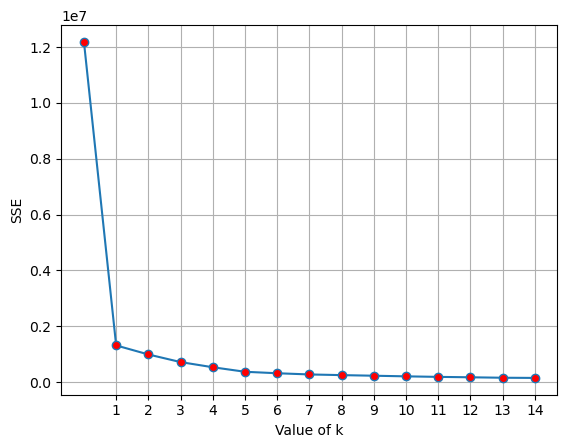

In [68]:
plt.xlabel('Value of k')
plt.ylabel('SSE')
plt.xticks(range(1,26))
plt.plot(sse, marker = 'o', mfc = 'r')
plt.grid()

In [69]:
from kneed import KneeLocator

In [71]:
kl = KneeLocator(range(1,16), sse, curve= 'convex',
                direction= 'decreasing')

In [72]:
kl.elbow

2